FCFS

In [ ]:
import random 
import pandas as pd
import matplotlib.pyplot as plt

n = int(input("No of Process: "))
process = []
for i in range(n):
    process.append({
        'PID' : f"P{i+1}",
        'AT' : random.randint(0,10),
        'BT' : random.randint(1, 10)
    })

process.sort(key = lambda x:x['AT'])
ct = 0
tl = []

for p in process:
    if ct < p['AT']:
        tl.append(("Idle", ct, p['AT']))
        ct = p['AT']
    p['start'] = ct
    p['CT'] = p['start'] + p['BT']
    p['TAT'] = p['CT'] - p['AT']
    p['WT'] = p['TAT'] - p['BT']
    tl.append((p['PID'], p['start'], p['CT']))
    ct = p['CT']

print("cpu scheduling FCFS")
df = pd.DataFrame(process).sort_values(by='PID')
print(df.to_string(index=False))
print(f"average tat: {df['TAT'].mean()}")
print(f"average wt:  {df['WT'].mean()}")

fig, ax = plt.subplots(figsize=(10, 5))
up = df['PID'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in tl:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

Non preemptive SJF

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

n = int(input("Enter number of process:"))
process = []

for i in range(n):
    process.append({
        'pid':f"p{i+1}",
        'at': random.randint(0,10),
        'bt': random.randint(1, 10),
        'cm': False
    })

cmpc = 0
ct = 0
tl = []

while cmpc < n:
    avail = [p for p in process if not p['cm'] and p['at'] <= ct]
    
    if not avail:
        nxj = min(p['at'] for p in process if not p['cm'])
        tl.append(('Idle', ct, nxj))
        ct = nxj
    else:
        shj = min(avail, key=lambda x : (x['bt'], x['at']))

        shj['ct'] = ct + shj['bt']
        shj['tat'] = shj['ct'] - shj['at']
        shj['wt'] = shj['tat'] - shj['bt']

        tl.append((shj['pid'], ct,shj['ct']))
        shj['cm'] = True
        cmpc += 1
        ct = shj['ct']


df = pd.DataFrame(process)
print("cpu scheduling non SJF")
print(df.to_string(index=False))
print(f"average tat: {df['TAT'].mean()}")
print(f"average wt:  {df['WT'].mean()}")

fig, ax = plt.subplots(figsize=(10, 5))
up = df['pid'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in tl:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

preemptive SJF

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd

processes = []
n = int(input("Enter number of processes: "))
for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RT': bt,  
        'Completed': False
    })

current_time = 0
completed_count = 0
timeline = [] 
total_tat = 0
total_wt = 0

def record_history(label, start, end):
    if not timeline:
        timeline.append((label, start, end))
        return
    last_lbl, last_start, last_end = timeline[-1]
    
    if last_lbl == label and last_end == start:
        timeline[-1] = (label, last_start, end)
    else:
        timeline.append((label, start, end))

while completed_count < n:
    available = [p for p in processes if p['AT'] <= current_time and not p['Completed']]

    if not available:
        record_history('Idle', current_time, current_time + 1)
        current_time += 1
        continue
    shortest_job = min(available, key=lambda x: (x['RT'], x['AT']))

    shortest_job['RT'] -= 1
    record_history(shortest_job['PID'], current_time, current_time + 1)
    current_time += 1

    if shortest_job['RT'] == 0:
        shortest_job['Completed'] = True
        completed_count += 1
        shortest_job['CT'] = current_time
        shortest_job['TAT'] = shortest_job['CT'] - shortest_job['AT']
        shortest_job['WT'] = shortest_job['TAT'] - shortest_job['BT']
        
        total_tat += shortest_job['TAT']
        total_wt += shortest_job['WT']

avg_tat = total_tat / n
avg_wt = total_wt / n

df = pd.DataFrame(processes)
df = df[['PID', 'AT', 'BT', 'CT','WT','TAT']].sort_values(by='PID')

print("Preemptive SJF Results")
print(df.to_string(index=False))
print(f"average tat: {df['TAT'].mean()}")
print(f"average wt:  {df['WT'].mean()}")

fig, ax = plt.subplots(figsize=(10, 5))
up = df['PID'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in timeline:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

Non preemptive Priority

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd

n = int(input("Enter number of processes: "))

process = []

for i in range(n):
    process.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'Priority': random.randint(1, 5),
        'cm':False
    })

ct = 0
tl = []
cmpc = 0

while cmpc < n:
    available = [p for p in process if p['AT'] <= ct and not p['cm']]

    if not available:
        nt = min(p['AT'] for p in process if not p['cm'])
        tl.append(('Idle', ct, nt))
        ct = nt
        continue

    p = min(available, key=lambda x: (x['Priority'], x['AT']))

    s = ct
    e = s + p['BT']

    p['CT'] = e
    p['TAT'] = e - p['AT']
    p['WT'] = p['TAT'] - p['BT']

    tl.append((p['PID'], s, e))
    ct = e
    p['cm'] = True
    cmpc += 1

df = pd.DataFrame(process).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("Non Preemptive Priority")
print(df[['PID','AT','BT','Priority','CT','TAT','WT']].to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")


fig, ax = plt.subplots(figsize=(10, 5))
up = df['PID'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in tl:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

preemptive Priority

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

n = int(input("Enter number of processes: "))

processes = []
for i in range(n):
    bt = random.randint(1,10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RBT': bt,
        'Priority': random.randint(1, 5),
    })


ct = 0
cmpc = 0
tl = []

def hp(l, s, e):
    if not tl:
        tl.append((l, s, e))
        return
    lsl, lss, lse = tl[-1]

    if lsl == l and lse == s:
        tl[-1] = (l, lss, e)
    else:
        tl.append((l, s, e))


while cmpc < n:
    available = [p for p in processes if p['AT'] <= ct and p['RBT'] > 0]

    if not available:
        hp('Idle', ct, ct+1)
        ct += 1
        continue

    cur = min(available, key=lambda x: (x['Priority'], x['AT']))

    hp(cur['PID'], ct, ct+1)

    cur['RBT'] -= 1
    ct += 1

    if cur['RBT'] == 0:
        cur['CT'] = ct
        cur['TAT'] = cur['CT'] - cur['AT']
        cur['WT'] = cur['TAT'] - cur['BT']
        cmpc += 1

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("\nPreemptive Priority Scheduler Results")
print(df.to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
up = df['PID'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in tl:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

Round Robin

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

n = int(input("Enter number of processes: "))
tq = int(input("Enter Time Quantum: "))

processes = []
for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'pid': f'P{i+1}',
        'at': random.randint(0, 10),
        'bt': bt,
        'rbt': bt
    })
    
processes.sort(key=lambda x: x['at'])

time = 0
queue = deque()
timeline = []
i = 0

if processes[0]['at'] > time:
    timeline.append(('Idle', time, processes[0]['at']))
    time = processes[0]['at']
.
queue.append(processes[0])
i = 1

completed = []

while queue or i < n:
    
    while i < n and processes[i]['at'] <= time:
        queue.append(processes[i])
        i += 1

    if not queue:
        next_time = processes[i]['at']
        timeline.append(('Idle', time, next_time))
        time = next_time
        continue

    p = queue.popleft()
    exec_time = min(tq, p['rbt'])

    start = time
    time += exec_time
    p['rbt'] -= exec_time

    timeline.append((p['pid'], start, time))

    while i < n and processes[i]['at'] <= time:
        queue.append(processes[i])
        i += 1

    if p['rbt'] > 0:
        queue.append(p)
    else:
        p['ct'] = time
        p['tat'] = p['ct'] - p['at']
        p['wt'] = p['tat'] - p['bt']
        completed.append(p)


df = pd.DataFrame(processes).sort_values(by='pid')

avg_tat = df['tat'].mean()
avg_wt = df['wt'].mean()
print(df.to_string(index=False))
print(f"\nAverage WT: {avg_wt:.2f}")
print(f"Average TAT: {avg_tat:.2f}")


fig, ax = plt.subplots(figsize=(10, 5))
up = df['pid'].unique()
yp = {pid : i for i, pid in enumerate(up)}

for l, s, e in timeline:
    d = e-s
    if l == 'Idle':
        ax.broken_barh([(s, d)], (-0.5, len(up)), color='tab:red')
    else:
        y = yp[l]
        ax.broken_barh([(s, d)], (y-0.5, 0.8))

ax.set_yticks(range(len(up)))
ax.set_yticklabels(yp.keys())
plt.show()

##### Deadlock

In [ ]:
n = int(input("Enter number of processes (n): "))
m = int(input("Enter number of resource types (m): "))

print("\nEnter TOTAL resources in the system:")
total = list(map(int, input(f"Enter {m} values: ").split()))
if len(total) != m:
    print("ERROR: Total resource vector size must match number of resources.")
    exit()

print("\nEnter MAX matrix:")
max_matrix = []
for i in range(n):
    row = list(map(int, input(f"Enter {m} values for Process P{i}: ").split()))
    if len(row) != m:
        print("ERROR: Incorrect number of resource values.")
        exit()
    for j in range(m):
        if row[j] > total[j]:
            print(f"ERROR: Process P{i} max demand exceeds total system resources.")
            exit()
    max_matrix.append(row)

print("\nEnter ALLOCATION matrix:")
allocation = []
for i in range(n):
    row = list(map(int, input(f"Enter {m} values for Process P{i}: ").split()))
    if len(row) != m:
        print("ERROR: Incorrect number of resource values.")
        exit()
    for j in range(m):
        if row[j] > max_matrix[i][j]:
            print(f"ERROR: Allocation cannot exceed maximum demand for Process P{i}.")
            exit()
    allocation.append(row)

need = []
for i in range(n):
    row = []
    for j in range(m):
        value = max_matrix[i][j] - allocation[i][j]
        row.append(value)
    need.append(row)

allocated_sum = [0] * m
for j in range(m):
    for i in range(n):
        allocated_sum[j] += allocation[i][j]

for j in range(m):
    if allocated_sum[j] > total[j]:
        print("ERROR: Allocated resources exceed total system resources.")
        exit()

available = [total[j] - allocated_sum[j] for j in range(m)]

print("\nAvailable Resources (Calculated):", available)

work = available.copy()
finish = [False] * n
safe_sequence = []

print("\nInitial WORK:", work)
step = 1

while True:
    allocated_flag = False
    for i in range(n):
        if not finish[i] and all(need[i][j] <= work[j] for j in range(m)):
            print(f"\nStep {step}: Process P{i} executes")
            print("WORK before:", work)

            for j in range(m):
                work[j] += allocation[i][j]

            print("WORK after:", work)

            finish[i] = True
            safe_sequence.append(f"P{i}")
            allocated_flag = True
            step += 1

    if not allocated_flag:
        break

if all(finish):
    print("\nSYSTEM IS IN SAFE STATE")
    print("Safe Sequence:", " -> ".join(safe_sequence))
else:
    print("\nSYSTEM IS NOT IN SAFE STATE")

Memory Allocation

NO of blocks: 20
NO of files: 2
1.best 2.worst 3.fist 1



File_no  File_size  Block_no  Block_size  Fragment
--------------------------------------------------
1	14	B8	14	0
2	9	B6	12	3


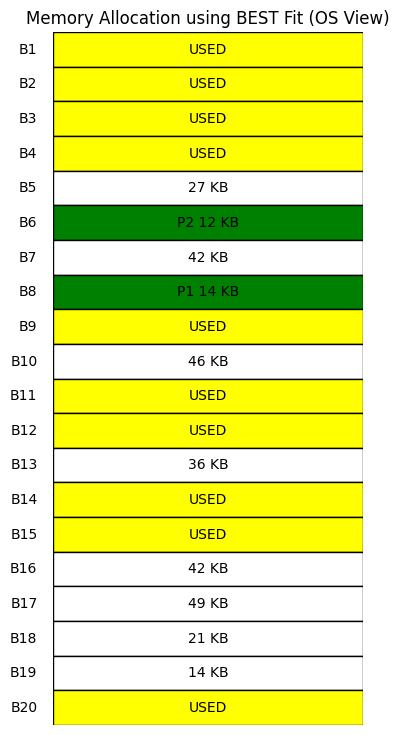

In [1]:
import random
import matplotlib.pyplot as plt

n_block = int(input("NO of blocks:"))
n_files = int(input("NO of files:"))
c = int(input("1.best 2.worst 3.fist"))

block_st = [random.randint(0,1) for _ in range(n_block)]
block_sz = [random.randint(10, 60) if b == 0 else 0 for b in block_st]
file_sz = [random.randint(5,30) for _ in range(n_files)]

free_block = [(block_sz[i], i) for i in range(n_block) if block_st[i] == 0]

allocation = [-1] * n_files
fragment   = [0] * n_files
used       = [False] * n_block

method="first"

if c == 1:
    free_block.sort()
    method="best"
elif c == 2:
    method="worst"
    free_block.sort(reverse=True)

for i in range(n_files):
    for sz, idx in free_block:
        if sz >= file_sz[i] and not used[idx]:
            allocation[i] = idx
            fragment[i] = sz - file_sz[i]
            used[idx] = True
            break

print("\nFile_no  File_size  Block_no  Block_size  Fragment")
print("-"*50)
for i in range(n_files):
    if allocation[i] != -1:
        print(f"{i+1}\t{file_sz[i]}\t{'B'+str(allocation[i]+1)}\t{block_sz[allocation[i]]}\t{fragment[i]}")
    else:
        print(f"{i+1:<8}{file_sz[i]:<11}{'NA':<10}{'NA':<12}{'NA'}")



block_to_file = {}
for i, b in enumerate(allocation):
    if b != -1:
        block_to_file[b] = f"P{i+1}"

fig, ax = plt.subplots(figsize=(4, 9))
ax.set(xlim=(0, 1), ylim=(0, n_block))
ax.axis("off")

for i in range(n_block):
    y = n_block - i - 1
    ax.text(-0.05, y + 0.5, f"B{i+1}", ha="right", va="center")
    
    if block_st[i] == 1:
        color = "yellow"
        text = "USED"
    elif used[i]:
        color = "green"
        label = block_to_file.get(i, "")
        text = f"{label} {block_sz[i]} KB"
    else:
        color = "white"
        text = f"{block_sz[i]} KB"

    ax.add_patch(plt.Rectangle((0, y), 1, 1, color=color, ec="black"))
    ax.text(0.5, y + 0.5, text, ha="center", va="center")

ax.set_title(f"Memory Allocation using {method.upper()} Fit (OS View)")
plt.show()

Paging

In [ ]:
import random
import math

page_size = int(input("Enter page size: "))
process_size = int(input("Enter process size: "))
memory_size = int(input("Enter memory size: "))

if page_size <= 0 or process_size <= 0 or memory_size <= 0:
    print("Invalid input")
    exit()

if memory_size % page_size != 0:
    print("Memory must be multiple of page size")
    exit()

num_pages = math.ceil(process_size / page_size)
num_frames = memory_size // page_size

if num_pages > num_frames:
    print("Not enough memory")
    exit()

offset_bits = int(math.log2(page_size))
page_bits = max(1, math.ceil(math.log2(num_pages)))
frame_bits = max(1, math.ceil(math.log2(num_frames)))
physical_bits = frame_bits + offset_bits

print("\nPages:", num_pages)
print("Frames:", num_frames)

frames = list(range(num_frames))
random.shuffle(frames)

page_table = {}
for i in range(num_pages):
    page_table[i] = frames[i]

print("\nPage Table:")
for p in page_table:
    print(f"Page {p} -> Frame {page_table[p]}")

print("\nAddress Mapping:\n")
for byte in range(process_size):
    page = byte // page_size
    offset = byte % page_size
    frame = page_table[page]
    physical = frame * page_size + offset

    byte_bin = format(byte, f'0{page_bits + offset_bits}b')
    page_bin = format(page, f'0{page_bits}b')
    offset_bin = format(offset, f'0{offset_bits}b')
    frame_bin = format(frame, f'0{frame_bits}b')
    physical_bin = format(physical, f'0{physical_bits}b')

    print(f"Byte {byte} ({byte_bin}) -> "
          f"(Page {page} ({page_bin}), Offset {offset} ({offset_bin})) -> "
          f"Frame {frame} ({frame_bin}) -> "
          f"Physical {physical} ({physical_bin})")

Page replacement

In [ ]:
import random
import matplotlib.pyplot as plt

def simulate(pages, capacity, algo):
    frames = []
    history = []
    status = []
    changes = []
    faults = 0
    pointer = 0         
    last_used = {}

    for i, page in enumerate(pages):

        if page in frames:
            status.append("HIT")
            changes.append("-")
        else:
            faults += 1
            status.append("FAULT")

            if len(frames) < capacity:
                frames.append(page)
                changes.append(f"->{page}")
            else:
                if algo == "FIFO":
                    idx = pointer
                    pointer = (pointer + 1) % capacity

                elif algo == "LRU":
                    lru_page = min(frames, key=lambda x: last_used.get(x, -1))
                    idx = frames.index(lru_page)

                elif algo == "OPTIMAL":
                    future = pages[i+1:]
                    idx = max(range(len(frames)), key=lambda j: future.index(frames[j]) if frames[j] in future else float('inf'))

                changes.append(f"{frames[idx]}->{page}")
                frames[idx] = page

        last_used[page] = i
        history.append(frames[:])

    return faults, history, status, changes
    
try:
    n = int(input("Ref string size: "))
    capacity = int(input("Frame slots: "))
    choice = int(input("1.FIFO  2.LRU  3.OPTIMAL\nChoice: "))
    algo = ["FIFO", "LRU", "OPTIMAL"][choice - 1]
except:
    exit("Invalid Input")

pages = [random.randint(1, 9) for _ in range(n)]

faults, history, status, changes = simulate(pages, capacity, algo)

print(f"\nAlgorithm: {algo}")
print(f"Frames: {capacity}")
print(f"Total Pages: {n}")
print(f"Hits: {n - faults}")
print(f"Faults: {faults}")
print("Ref String:", pages)

table = []
for i in range(capacity):      
    row = []
    for h in history:              
        if i < len(h):
            row.append(h[i])       
        else:
            row.append("")       
    table.append(row)
    
table += [status, changes]

rows = [f"Frame {i+1}" for i in range(capacity)] + ["Status", "Change"]

plt.figure(figsize=(10, 5))
plt.axis('off')

plt.table(cellText=table, rowLabels=rows, colLabels=list(map(str, pages)), loc='center', cellLoc='center')

plt.show()

frame allocation

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

n = int(input("Enter number of processes: "))
total_frames = int(input("Enter total number of frames: "))
min_frames = int(input("Enter minimum frames per process: "))

print("\nChoose Allocation Method:")
print("1. Minimum Allocation")
print("2. Equal Allocation")
print("3. Proportional Allocation")

choice = int(input("Enter choice (1/2/3): "))

processes = [f"P{i+1}" for i in range(n)]
sizes = [random.randint(5, 25) for _ in range(n)]

if choice == 1:
    allocated = [min_frames] * n
    title = "Minimum Frame Allocation"

elif choice == 2:
    allocated = [total_frames // n] * n
    title = "Equal Frame Allocation"

elif choice == 3:
    total_size = sum(sizes)
    allocated = [(s * total_frames) // total_size for s in sizes]
    title = "Proportional Frame Allocation"

else:
    print("Invalid choice")
    exit()

used_frames = sum(allocated)
free_frames = total_frames - used_frames


df = pd.DataFrame({
    "Process": processes,
    "Process_Size(Pages)": sizes,
    "Frames_Allocated": allocated
})

print("\nFrame Allocation Table:\n")
print(df.to_string(index=False))
print(f"\nUnallocated Frames: {free_frames}")

fig, ax = plt.subplots(figsize=(12, 3))

start = 0
colors = plt.cm.tab20.colors

for i in range(n):
    ax.barh(0, allocated[i], left=start, color=colors[i], label=processes[i])
    ax.text(start + allocated[i]/2, 0, processes[i])
    start += allocated[i]

if free_frames > 0:
    ax.barh(0, free_frames, left=start, color="gray", label="Free")
    ax.text(start + free_frames/2, 0, "Free", ha="center", va="center")

for f in range(total_frames + 1):
    ax.axvline(f, color="black", linewidth=0.3)

ax.set_xlim(0, total_frames)
ax.set_yticks([])

ax.set_xticks(range(0, total_frames + 1))

plt.tight_layout()
plt.show()

disk allocation 1

In [ ]:
import random
import matplotlib.pyplot as plt

def plot_graph(order, title):
    plt.figure(figsize=(12,6))  
    plt.plot(order, range(len(order)), marker='o')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.show()

def fcfs(queue, head):
    order = [head] + queue
    total = 0
    
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])
        
    print("\nFCFS")
    print("Service Order:", order)
    print("Total Head Movement:", total)
    
    plot_graph(order, "FCFS Disk Scheduling")


def sstf(queue, head):
    requests = queue.copy()
    current = head
    order = [head]
    total = 0

    for _ in range(len(requests)):
        nearest = requests[0]
        min_dist = abs(nearest - current)

        for r in requests:
            if abs(r - current) < min_dist:
                nearest = r
                min_dist = abs(r - current)

        total += min_dist
        current = nearest

        order.append(nearest)
        requests.remove(nearest)

    print("\nSSTF")
    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "SSTF Disk Scheduling")


def scan(queue, head, start, end, direction):
    left = [x for x in queue if x < head]
    right = [x for x in queue if x >= head]

    left.sort()
    right.sort()

    order = [head]

    if direction == "left":
        left.reverse()
        order += left
        order.append(start)
        order += right
    else:
        order += right
        order.append(end)
        left.reverse()
        order += left

    total = 0
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])

    print("\nSCAN")
    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "SCAN Disk Scheduling")

start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))

queue = [random.randint(start, end) for _ in range(qsize)]
head = random.randint(start, end)

print("\nGenerated Queue:", queue)
print("Head Position:", head)

print("\n----- Disk Scheduling Menu -----")
print("1. FCFS")
print("2. SSTF")
print("3. SCAN")

choice = int(input("Enter choice: "))


if choice == 1:
    fcfs(queue, head)

elif choice == 2:
    sstf(queue, head)

elif choice == 3:
    print("\nDirection:")
    print("1. Left")
    print("2. Right")

    d = input("Enter direction: ")

    if d == "1":
        direction = "left"
    elif d == "2":
        direction = "right"
    else:
        print("Invalid direction")
        exit()

    scan(queue, head, start, end, direction)

else:
    print("Invalid choice")

disk allocation 2

In [ ]:
import random
import matplotlib.pyplot as plt

def plot_graph(order, title):
    plt.figure(figsize=(12,6))  
    plt.plot(order, range(len(order)), marker='o')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.show()

def cscan(queue, head, start, end, direction):

    left = sorted([x for x in queue if x < head])
    right = sorted([x for x in queue if x >= head])

    order = [head]

    if direction == "right":
        order += right
        order.append(end)
        order.append(start)
        order += left

    else:  # left
        order += left[::-1]
        order.append(start)
        order.append(end)
        order += right[::-1]

    total = 0
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])

    print("\nC-SCAN ")
    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "C-SCAN Disk Scheduling")

def look(queue, head, direction):

    left = sorted([x for x in queue if x < head])
    right = sorted([x for x in queue if x >= head])

    order = [head]

    if direction == "right":
        order += right
        order += left[::-1]

    else:
        order += left[::-1]
        order += right

    total = 0
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])

    print("\nLOOK")
    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "LOOK Disk Scheduling")

def clook(queue, head, direction):

    left = sorted([x for x in queue if x < head])
    right = sorted([x for x in queue if x >= head])

    order = [head]

    if direction == "right":
        order += right
        order += left   

    else:
        order += left[::-1]  
        order += right[::-1]  

    total = 0
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])

    print("\nC-LOOK")
    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "C-LOOK Disk Scheduling")

start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))

queue = [random.randint(start, end) for _ in range(qsize)]
head = random.randint(start, end)

print("\nQueue:", queue)
print("Head:", head)

print("\n----- MENU -----")
print("1. C-SCAN")
print("2. LOOK")
print("3. C-LOOK")

choice = int(input("Enter choice: "))

print("\nDirection:")
print("1. Left")
print("2. Right")

d = int(input("Enter direction: "))

if d == 1:
    direction = "left"
elif d == 2:
    direction = "right"
else:
    print("Invalid direction")
    exit()

if choice == 1:
    cscan(queue, head, start, end, direction)

elif choice == 2:
    look(queue, head, direction)

elif choice == 3:
    clook(queue, head, direction)

else:
    print("Invalid choice")

file allocation 

In [ ]:
import random

n = int(input("Enter Number of Locations:"))

disk = [False]*n

for i in range(n):
    if random.random() < 0.4:
        disk[i] = True
print(["1" if i else "0" for i in disk])


print("1. seq")
print("2. link")
print("3. inde")

c = int(input("enter option: "))

num = int(input("enter number of files: "))

for i in range(1, num+1):
    s = random.randint(1, 5)
    print(f"f size: {s}")

    if c == 1:
        acc = False
        for i in range(n-s+1):
            if not any(disk[i: i+s]):
                for j in range(i, i+s):
                    disk[j] = True

                print("Allocated blocks:", list(range(i, i+s)))
                acc = True
                break
        if not acc:
            print("no space left")

    elif c == 2:
        free = [i for i in range(n) if not disk[i]]

        if len(free) < s:
            print("no space left")
        else:
            accblock = random.sample(free, s)
            for i in accblock:
                disk[i] = True

            print("Allocated blocks (linked):")
            print(" -> ".join(map(str, accblock)))

    elif c == 3:
        free = [i for i in range(n) if not disk[i]]

        if len(free) < s+1:
            print("no space left")
        else:
            index = free[0]
            accblock = random.sample(free[1:], s)

            disk[index] = True

            for i in accblock:
                disk[i] = True

            print("indexblock: ",index)
            print("datablocks: ",accblock)

    else:
        print("invalid")
        break
    
    print(["1" if i else "0" for i in disk])
